Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']

Số ảnh mỗi class:
  Leaf Blast                         : 360
  Sheath Blight                      : 352
  Brown Spot                         : 289
  Rice Hispa                         : 260
  Bacterial Leaf Blight              : 226
  Leaf scald                         : 220
  Healthy Rice Leaf                  : 193
  Narrow Brown Leaf Spot             : 126


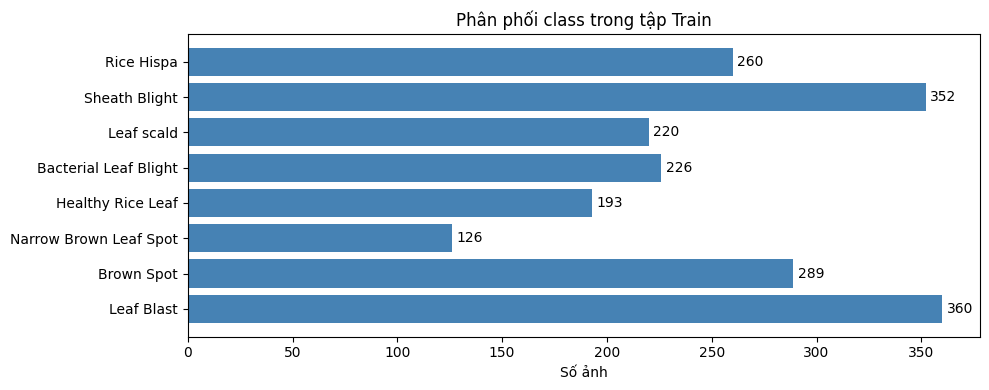


Kích thước ảnh mẫu:
  Leaf Blast: (1600, 1200) | mode: RGB
  Brown Spot: (1600, 1200) | mode: RGB
  Narrow Brown Leaf Spot: (1200, 1600) | mode: RGB


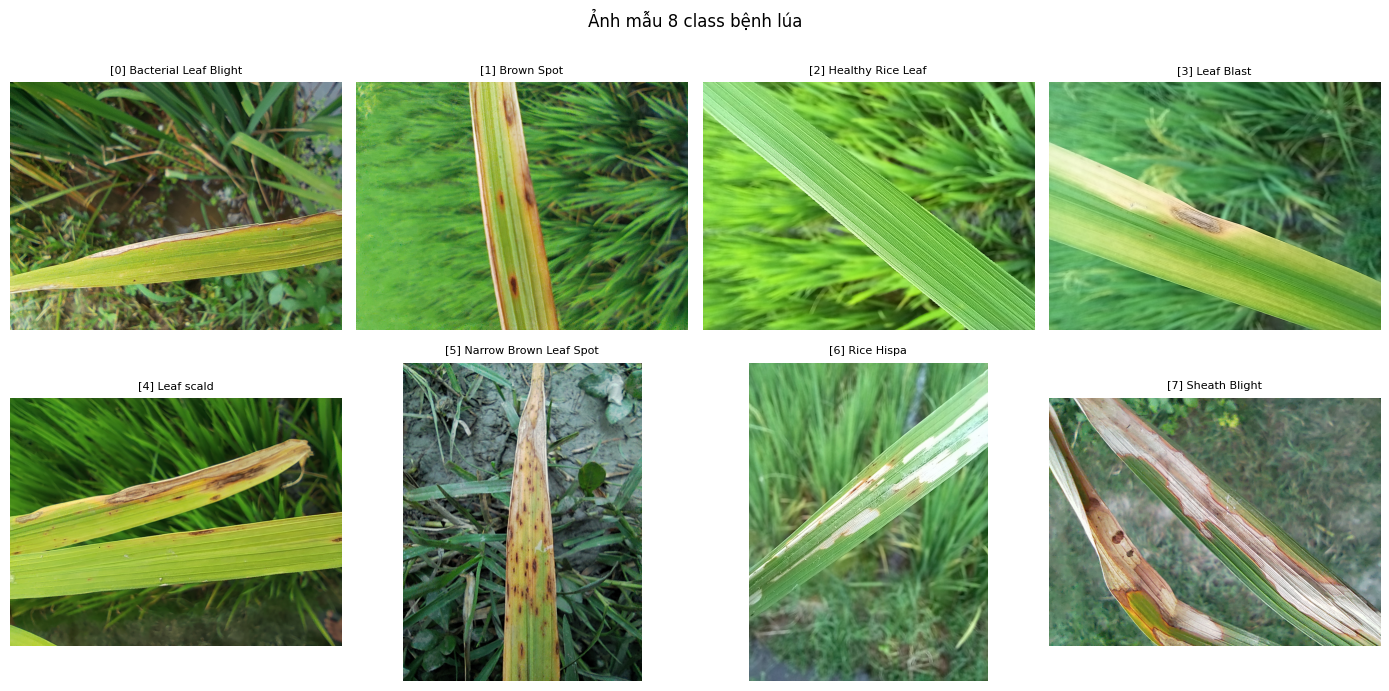


Số ảnh test: 900
Mẫu tên file test: ['private_0623.jpg', 'private_0764.jpg', 'private_0696.jpg', 'private_0293.jpg', 'private_0480.jpg']


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image

# Đường dẫn gốc đến dataset
BASE = "kaggle/input/competitions/fptu-can-tho-olympic-ai-2026"
TRAIN_DIR = os.path.join(BASE, "train")    # Thư mục ảnh train
TEST_DIR  = os.path.join(BASE, "test_speedup")  # Thư mục ảnh test

# Đọc file ánh xạ tên class -> index
with open(os.path.join(BASE, "label_mapping.json")) as f:
    label_map = json.load(f)

# Đảo ngược: index -> tên class (dùng khi decode kết quả dự đoán)
idx_to_class = {v: k for k, v in label_map.items()}
print("Classes:", list(label_map.keys()))

# Đếm số ảnh trong mỗi class của tập train
class_counts = {}
for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):  # Chỉ xét thư mục, bỏ qua file lẻ
        class_counts[cls] = len(os.listdir(cls_path))

print("\nSố ảnh mỗi class:")
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):  # Sắp xếp giảm dần
    print(f"  {cls:35s}: {cnt}")

# Vẽ biểu đồ cột ngang thể hiện phân phối số ảnh theo class
fig, ax = plt.subplots(figsize=(10, 4))
classes = list(class_counts.keys())
counts  = [class_counts[c] for c in classes]
bars = ax.barh(classes, counts, color="steelblue")
ax.bar_label(bars, padding=3)  # Hiển thị số lượng ở đầu mỗi cột
ax.set_xlabel("Số ảnh")
ax.set_title("Phân phối class trong tập Train")
plt.tight_layout()
plt.savefig("eda_class_distribution.png")  # Lưu ảnh biểu đồ
plt.show()

# Kiểm tra kích thước và định dạng màu của ảnh mẫu (3 class đầu tiên)
print("\nKích thước ảnh mẫu:")
for cls in list(os.listdir(TRAIN_DIR))[:3]:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        sample = os.listdir(cls_path)[0]  # Lấy ảnh đầu tiên trong thư mục
        img = Image.open(os.path.join(cls_path, sample))
        print(f"  {cls}: {img.size} | mode: {img.mode}")  # size=(W,H), mode=RGB/RGBA/...

# Hiển thị 1 ảnh đại diện cho mỗi class (tổng 8 class)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))  # Lưới 2 hàng x 4 cột
axes = axes.flatten()  # Chuyển mảng 2D thành 1D để dễ duyệt
for i, cls in enumerate(sorted(label_map.keys())):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]  # Lấy ảnh đầu tiên
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(f"[{label_map[cls]}] {cls}", fontsize=8)  # Tiêu đề: [index] tên class
    axes[i].axis("off")  # Ẩn trục tọa độ
plt.suptitle("Ảnh mẫu 8 class bệnh lúa", fontsize=12)
plt.tight_layout()
plt.savefig("eda_sample_images.png")
plt.show()

# Đếm và in thông tin ảnh trong tập test
test_imgs = os.listdir(TEST_DIR)
print(f"\nSố ảnh test: {len(test_imgs)}")
print("Mẫu tên file test:", test_imgs[:5])  # In 5 tên file đầu để kiểm tra định dạng

In [2]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from PIL import Image
import pandas as pd
import time
from tqdm import tqdm
import torchvision.transforms.functional as TF

# ========================= CONFIG =========================
IMG_SIZE    = 336          # Kích thước ảnh đầu vào (px)
BATCH_SIZE  = 28           # Số ảnh mỗi batch
EPOCHS      = 50           # Số vòng huấn luyện tối đa
LR          = 2.8e-4       # Learning rate ban đầu
NUM_CLASSES = 8            # Số class bệnh lúa
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"  # Ưu tiên GPU nếu có
MODEL_NAME  = "efficientnet_b3"

print(f"Device: {DEVICE}")
print(f"Model : {MODEL_NAME}  |  IMG_SIZE: {IMG_SIZE}")

# ========================= DATASET =========================
class RiceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Đọc ảnh, ép về RGB để tránh lỗi ảnh RGBA hoặc grayscale
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Duyệt từng class, thu thập đường dẫn ảnh và nhãn tương ứng
all_paths, all_labels = [], []
for cls_name, cls_idx in label_map.items():
    cls_path = os.path.join(TRAIN_DIR, cls_name)
    for fname in os.listdir(cls_path):
        all_paths.append(os.path.join(cls_path, fname))
        all_labels.append(cls_idx)

# ========================= NOISE FUNCTIONS =========================
# Các hàm tạo nhiễu giả lập điều kiện ảnh test bị nhiễu thực tế

def add_horizontal_stripe(img):
    # Tạo sọc ngang bằng cách tối dần từng hàng pixel theo bước nhảy ngẫu nhiên
    arr = np.array(img).astype(np.float32)
    step = random.randint(2, 7)
    intensity = random.uniform(0.08, 0.55)
    for i in range(0, arr.shape[0], step):
        arr[i, :] *= intensity
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_color_glitch(img):
    # Mô phỏng lỗi màu: hoán đổi kênh R↔B, đảo ngược kênh, hoặc dịch màu ngang
    arr = np.array(img).copy()
    mode = random.randint(0, 2)
    if mode == 0:        # R↔B swap
        arr[:, :, 0], arr[:, :, 2] = arr[:, :, 2].copy(), arr[:, :, 0].copy()
    elif mode == 1:      # Invert channel
        ch = random.randint(0, 2)
        arr[:, :, ch] = 255 - arr[:, :, ch]
    else:                # Chromatic shift
        shift = random.randint(3, 10)
        arr[:, shift:, 0] = arr[:, :-shift, 0]
    return Image.fromarray(arr)

def add_darkening(img):
    # Làm tối toàn bộ ảnh (giả lập thiếu sáng nhẹ)
    factor = random.uniform(0.04, 0.22)
    arr = np.array(img).astype(np.float32) * factor
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_vignette(img):
    # Hiệu ứng vignette: vùng trung tâm sáng, rìa ảnh tối dần
    arr = np.array(img).astype(np.float32)
    h, w = arr.shape[:2]
    Y, X = np.ogrid[:h, :w]
    cx, cy = w / 2, h / 2
    dist = np.sqrt(((X - cx) / cx) ** 2 + ((Y - cy) / cy) ** 2)
    mask = 1.0 - np.clip(dist * random.uniform(0.5, 1.3), 0, 1)
    arr *= mask[:, :, np.newaxis]
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_grid_noise(img):
    # Tạo lưới nhiễu bằng cách tối hàng và cột theo bước đều
    arr = np.array(img).astype(np.float32)
    step = random.randint(2, 5)
    intensity = random.uniform(0.25, 0.65)
    arr[::step, :] *= intensity
    arr[:, ::step] *= intensity
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_chromatic_aberration(img, max_shift=14):
    # Dịch kênh đỏ sang phải và kênh xanh sang trái, giả lập lỗi quang học
    arr = np.array(img)
    shift = random.randint(4, max_shift)
    arr[:, shift:, 0] = arr[:, :-shift, 0]
    arr[:, :-shift, 2] = arr[:, shift:, 2]
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_moire_grid(img):
    # Tạo hiệu ứng moiré (lưới chồng chéo) làm mờ chi tiết cục bộ
    arr = np.array(img).astype(np.float32)
    step = random.randint(3, 8)
    intensity = random.uniform(0.20, 0.58)
    arr[::step, ::step] *= intensity
    arr[::step+1, ::step+1] *= intensity
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_heavy_blur(img):
    # Làm mờ mạnh bằng Gaussian blur với kernel và sigma ngẫu nhiên
    return transforms.GaussianBlur(kernel_size=random.choice([5, 7, 9, 11]),
                                   sigma=random.uniform(1.2, 3.8))(img)

def add_extreme_low_light(img):
    # Giả lập ảnh chụp thiếu sáng nặng + thêm noise Gaussian
    factor = random.uniform(0.02, 0.20)
    arr = np.array(img).astype(np.float32) * factor
    noise = np.random.normal(0, 9, arr.shape).astype(np.float32)
    arr += noise
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

# ========================= TRANSFORMS =========================
# Augmentation mạnh cho train để model học được ảnh nhiễu đa dạng
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 72, IMG_SIZE + 72)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.58, 1.0), ratio=(0.75, 1.45)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.35),
    transforms.RandomRotation(degrees=40),
    transforms.RandomPerspective(distortion_scale=0.28, p=0.25),

    # Áp dụng ngẫu nhiên các loại nhiễu để cover test set thực tế
    transforms.RandomApply([transforms.Lambda(add_horizontal_stripe)], p=0.48),
    transforms.RandomApply([transforms.Lambda(add_chromatic_aberration)], p=0.48),
    transforms.RandomApply([transforms.Lambda(add_color_glitch)], p=0.38),
    transforms.RandomApply([transforms.Lambda(add_grid_noise)], p=0.32),
    transforms.RandomApply([transforms.Lambda(add_moire_grid)], p=0.28),
    transforms.RandomApply([transforms.Lambda(add_vignette)], p=0.30),
    transforms.RandomApply([transforms.Lambda(add_heavy_blur)], p=0.25),
    transforms.RandomApply([transforms.Lambda(add_extreme_low_light)], p=0.22),
    transforms.RandomApply([transforms.Lambda(add_darkening)], p=0.18),

    transforms.ColorJitter(brightness=0.45, contrast=0.45, saturation=0.35, hue=0.12),
    transforms.RandomGrayscale(p=0.18),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # Chuẩn hóa ImageNet
    transforms.RandomErasing(p=0.38, scale=(0.03, 0.18), ratio=(0.25, 4.0)),  # Xóa ngẫu nhiên vùng ảnh
])

# Validation có nhiễu nhẹ để chọn model tốt nhất trên dữ liệu gần với test thực tế
noisy_val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 48, IMG_SIZE + 48)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomApply([transforms.Lambda(add_horizontal_stripe)], p=0.30),
    transforms.RandomApply([transforms.Lambda(add_chromatic_aberration)], p=0.30),
    transforms.RandomApply([transforms.Lambda(add_color_glitch)], p=0.22),
    transforms.RandomApply([transforms.Lambda(add_grid_noise)], p=0.18),
    transforms.RandomApply([transforms.Lambda(add_vignette)], p=0.20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Validation sạch: chỉ resize và normalize, không augment
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ========================= SPLIT + SAMPLER =========================
# Chia 82% train / 18% val, stratify để giữ tỉ lệ class đồng đều
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.18, stratify=all_labels, random_state=42)

train_ds     = RiceDataset(train_paths, train_labels, train_transform)
val_ds       = RiceDataset(val_paths, val_labels, val_transform)
noisy_val_ds = RiceDataset(val_paths, val_labels, noisy_val_transform)

# WeightedRandomSampler: class ít ảnh được sample nhiều hơn, tránh mất cân bằng
class_sample_counts = np.bincount(train_labels)
weights_per_class   = 1.0 / class_sample_counts
sample_weights      = torch.tensor([weights_per_class[l] for l in train_labels], dtype=torch.float)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

def seed_everything(seed=42):
    # Cố định seed toàn bộ để kết quả tái lập được
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

def seed_worker(worker_id):
    # Cố định seed riêng cho từng worker của DataLoader
    np.random.seed(42 + worker_id)
    random.seed(42 + worker_id)

g = torch.Generator().manual_seed(42)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                      num_workers=2, pin_memory=True, worker_init_fn=seed_worker, generator=g)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2, pin_memory=True, worker_init_fn=seed_worker, generator=g)
noisy_val_dl = DataLoader(noisy_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, worker_init_fn=seed_worker, generator=g)

print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")

# ========================= MODEL =========================
# Load EfficientNet-B3 pretrained từ timm, thay head cuối thành NUM_CLASSES
# drop_rate và drop_path_rate giúp giảm overfitting
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES,
                          drop_rate=0.25, drop_path_rate=0.15).to(DEVICE)

# ========================= LOSS / OPTIM / SCHEDULER =========================
# Label smoothing 0.09: tránh model quá tự tin vào nhãn, cải thiện generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.09)

# AdamW với weight decay để regularize
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# OneCycleLR: LR tăng nhanh rồi giảm dần theo cosine, hiệu quả hơn fixed LR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_dl), epochs=EPOCHS,
    pct_start=0.12, anneal_strategy='cos'
)

# ========================= TRAINING =========================
best_score = 0.0
patience   = 12   # Dừng sớm nếu không cải thiện sau 12 epoch liên tiếp
counter    = 0
best_epoch = 0

print(f"\n=== TRAINING — {MODEL_NAME} (IMG_SIZE={IMG_SIZE}) ===\n")

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    train_loss = 0.0
    train_preds_ep, train_true_ep = [], []

    for imgs, labels in tqdm(train_dl, desc=f"Epoch {epoch+1:02d} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()       # Tính gradient
        optimizer.step()      # Cập nhật trọng số
        scheduler.step()      # Cập nhật learning rate

        train_loss += loss.item()
        preds = out.detach().argmax(dim=1).cpu().numpy()
        train_preds_ep.extend(preds)
        train_true_ep.extend(labels.cpu().numpy())

    avg_train_loss = train_loss / len(train_dl)
    train_f1 = f1_score(train_true_ep, train_preds_ep, average="macro")

    # Đánh giá trên val sạch
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():    # Không tính gradient khi eval để tiết kiệm bộ nhớ
        for imgs, labels in val_dl:
            preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(labels.numpy())
    val_f1 = f1_score(all_true, all_preds, average="macro")

    # Đánh giá trên val nhiễu
    all_preds_noisy, all_true_noisy = [], []
    with torch.no_grad():
        for imgs, labels in noisy_val_dl:
            preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds_noisy.extend(preds)
            all_true_noisy.extend(labels.numpy())
    noisy_val_f1 = f1_score(all_true_noisy, all_preds_noisy, average="macro")

    gap         = train_f1 - val_f1  # Chênh lệch train/val, theo dõi overfitting
    blend_score = 0.75 * val_f1 + 0.25 * noisy_val_f1  # Điểm tổng hợp để lưu model tốt nhất
    elapsed     = time.time() - start

    print(f"Epoch {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Train F1: {train_f1:.4f} | "
          f"Val F1: {val_f1:.4f} | Noisy Val: {noisy_val_f1:.4f} | Blend: {blend_score:.4f} | Gap: {gap:.3f} | Time: {elapsed:.1f}s")

    # Lưu model nếu blend score cải thiện
    if blend_score > best_score:
        best_score = blend_score
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "kaggle/working/best_model.pth")
        counter = 0
        print(f"   >>> Saved best model at epoch {best_epoch} (Blend = {best_score:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")  # Dừng sớm để tránh lãng phí thời gian
            break

print(f"\nBest Blend Score: {best_score:.4f} at epoch {best_epoch}")

Device: cuda
Model : efficientnet_b3  |  IMG_SIZE: 336
Train size: 1661 | Val size: 365



=== TRAINING — efficientnet_b3 (IMG_SIZE=336) ===



Epoch 01 [Train]: 100%|██████████| 60/60 [00:59<00:00,  1.01it/s]


Epoch 01 | Loss: 3.6087 | Train F1: 0.1315 | Val F1: 0.1133 | Noisy Val: 0.1063 | Blend: 0.1116 | Gap: 0.018 | Time: 75.6s
   >>> Saved best model at epoch 1 (Blend = 0.1116)


Epoch 02 [Train]: 100%|██████████| 60/60 [00:59<00:00,  1.01it/s]


...

Epoch 48 | Loss: 0.9651 | Train F1: 0.7731 | Val F1: 0.9434 | Noisy Val: 0.8885 | Blend: 0.9297 | Gap: -0.170 | Time: 77.5s


Epoch 49 [Train]: 100%|██████████| 60/60 [01:00<00:00,  1.02s/it]


Epoch 49 | Loss: 0.9802 | Train F1: 0.7590 | Val F1: 0.9323 | Noisy Val: 0.8968 | Blend: 0.9234 | Gap: -0.173 | Time: 77.1s


Epoch 50 [Train]: 100%|██████████| 60/60 [01:00<00:00,  1.01s/it]


Epoch 50 | Loss: 0.9898 | Train F1: 0.7590 | Val F1: 0.9367 | Noisy Val: 0.9021 | Blend: 0.9280 | Gap: -0.178 | Time: 76.8s

Best Blend Score: 0.9330 at epoch 45


In [5]:
import os, json, numpy as np, pandas as pd
import torch, torch.nn as nn
import timm
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm

# ========================= CONFIG =========================
IMG_SIZE    = 336
NUM_CLASSES = 8
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME  = "efficientnet_b3"

BASE     = "kaggle/input/competitions/fptu-can-tho-olympic-ai-2026"
TEST_DIR = os.path.join(BASE, "test_speedup")

with open(os.path.join(BASE, "label_mapping.json")) as f:
    label_map = json.load(f)

# ========================= LOAD MODEL =========================
model = timm.create_model(MODEL_NAME, pretrained=False,
                          num_classes=NUM_CLASSES,
                          drop_rate=0.25, drop_path_rate=0.15).to(DEVICE)

model.load_state_dict(torch.load("kaggle/working/best_model.pth", map_location=DEVICE))
model.eval()
print(f"Loaded best_model.pth | Device: {DEVICE}")

# ========================= NOISE FUNCTIONS =========================
def add_horizontal_stripe(img):
    import random
    arr = np.array(img).astype(np.float32)
    step = random.randint(2, 7)
    intensity = random.uniform(0.08, 0.55)
    for i in range(0, arr.shape[0], step):
        arr[i, :] *= intensity
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

def add_color_glitch(img):
    import random
    arr = np.array(img).copy()
    mode = random.randint(0, 2)
    if mode == 0:
        arr[:, :, 0], arr[:, :, 2] = arr[:, :, 2].copy(), arr[:, :, 0].copy()
    elif mode == 1:
        ch = random.randint(0, 2)
        arr[:, :, ch] = 255 - arr[:, :, ch]
    else:
        shift = random.randint(3, 10)
        arr[:, shift:, 0] = arr[:, :-shift, 0]
    return Image.fromarray(arr)

def add_chromatic_aberration(img, max_shift=14):
    import random
    arr = np.array(img)
    shift = random.randint(4, max_shift)
    arr[:, shift:, 0] = arr[:, :-shift, 0]
    arr[:, :-shift, 2] = arr[:, shift:, 2]
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

# ========================= DATASET + TTA TRANSFORMS =========================
class TestDataset(Dataset):
    def __init__(self, folder, transform):
        self.files     = sorted(os.listdir(folder))  # Sắp xếp để đảm bảo thứ tự nhất quán
        self.folder    = folder
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # Đọc ảnh và ép về RGB, trả về ảnh đã transform kèm tên file
        img = Image.open(os.path.join(self.folder, self.files[idx])).convert("RGB")
        return self.transform(img), self.files[idx]

# ========================= TTA INFERENCE =========================
# TTA (Test Time Augmentation): chạy inference nhiều lần với các biến thể khác nhau
# rồi trung bình xác suất → kết quả ổn định hơn so với chỉ predict 1 lần

_norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa ImageNet

tta_transforms = [
    # 1. Ảnh gốc resize chuẩn
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), _norm]),

    # 2. Lật ngang (horizontal flip)
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.Lambda(TF.hflip), transforms.ToTensor(), _norm]),

    # 3. Resize lớn hơn rồi crop trung tâm (scale nhỏ hơn 1 chút)
    transforms.Compose([transforms.Resize((IMG_SIZE+48, IMG_SIZE+48)), transforms.CenterCrop(IMG_SIZE), transforms.ToTensor(), _norm]),

    # 4. Resize lớn hơn nhiều rồi crop trung tâm (zoom out nhiều hơn)
    transforms.Compose([transforms.Resize((IMG_SIZE+80, IMG_SIZE+80)), transforms.CenterCrop(IMG_SIZE), transforms.ToTensor(), _norm]),

    # 5. Lật dọc (vertical flip)
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.Lambda(TF.vflip), transforms.ToTensor(), _norm]),

    # 6. Giả lập nhiễu chromatic aberration (lỗi quang học màu sắc)
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.Lambda(add_chromatic_aberration), transforms.ToTensor(), _norm]),

    # 7. Giả lập nhiễu sọc ngang
    transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.Lambda(add_horizontal_stripe), transforms.ToTensor(), _norm]),

    # 8. Resize + crop + nhiễu màu (color glitch)
    transforms.Compose([transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)), transforms.CenterCrop(IMG_SIZE),
                        transforms.Lambda(add_color_glitch), transforms.ToTensor(), _norm]),
]

# Load trọng số model tốt nhất đã lưu trong quá trình train
model.load_state_dict(torch.load("kaggle/working/best_model.pth", map_location=DEVICE))
model.eval()

all_probs  = []   # Lưu xác suất từng TTA round: shape (num_tta, num_samples, num_classes)
all_fnames = []   # Lưu tên file ảnh test (chỉ cần lấy 1 lần ở round đầu)

for i, t in enumerate(tta_transforms):
    test_ds = TestDataset(TEST_DIR, t)
    test_dl = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

    probs_round  = []
    fnames_round = []

    with torch.no_grad():   # Không cần gradient khi inference
        for imgs, fnames in tqdm(test_dl, desc=f"TTA {i+1}/{len(tta_transforms)}"):
            # Softmax để chuyển logit thành xác suất (tổng = 1)
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu().numpy()
            probs_round.append(probs)
            fnames_round.extend(fnames)

    all_probs.append(np.vstack(probs_round))  # Gộp toàn bộ batch trong round này

    if i == 0:
        all_fnames = fnames_round  # Chỉ lấy tên file 1 lần (các round sau giống hệt)

    print(f"TTA round {i+1}/{len(tta_transforms)} done")

# Trung bình xác suất qua tất cả TTA round, sau đó lấy class có xác suất cao nhất
avg_probs   = np.mean(all_probs, axis=0)   # shape: (num_samples, num_classes)
final_preds = avg_probs.argmax(axis=1)     # Lấy index class có prob lớn nhất

# Tạo file submission theo định dạng yêu cầu
submission = pd.DataFrame({"image_id": all_fnames, "label": final_preds})
submission.to_csv("kaggle/working/submission.csv", index=False)

print("Submission saved!")
print(submission["label"].value_counts().sort_index())  # Kiểm tra phân phối nhãn dự đoán

TTA 1/8: 100%|██████████| 57/57 [00:17<00:00,  3.23it/s]


TTA round 1/8 done


TTA 2/8: 100%|██████████| 57/57 [00:18<00:00,  3.17it/s]


TTA round 2/8 done


TTA 3/8: 100%|██████████| 57/57 [00:18<00:00,  3.16it/s]


...

TTA round 6/8 done


TTA 7/8: 100%|██████████| 57/57 [00:18<00:00,  3.16it/s]


TTA round 7/8 done


TTA 8/8: 100%|██████████| 57/57 [00:18<00:00,  3.08it/s]

TTA round 8/8 done
Submission saved!
label
0     97
1    159
2     60
3     86
4    120
5     61
6    127
7    190
Name: count, dtype: int64
